In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class BernoulliNB_General:
    def __init__(self, binarize_threshold=0.5, alpha=1.0):
        self.threshold = binarize_threshold
        self.alpha = alpha
        self.feature_probs = None 
        self.priors = None        
        self.classes = None

    def predict(self, X):
        X_bin = (X > self.threshold).astype(int)
        # Tính toán Log-prob (tránh underflow)
        log_probs = np.zeros((len(X), len(self.classes)))
        
        for idx, c in enumerate(self.classes):
            log_prior = np.log(self.priors[idx])
            p = self.feature_probs[idx]
            
            # Xử lý epsilon y hệt lúc train để kết quả khớp 100%
            epsilon = 1e-9 
            p = np.clip(p, epsilon, 1 - epsilon)
            
            # Công thức log-likelihood Bernoulli
            log_likelihood = np.sum(X_bin * np.log(p) + (1 - X_bin) * np.log(1 - p), axis=1)
            log_probs[:, idx] = log_prior + log_likelihood
            
        return self.classes[np.argmax(log_probs, axis=1)]

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, 
                 value=None, gini=None, samples=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.gini = gini
        self.samples = samples
    
    def is_leaf_node(self):
        return self.value is not None

class DecisionTreeClassifier:
    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.root = None
        self.n_features = None
        self.n_classes = None
        self.feature_importances_ = None
        
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        
        # Logic duyệt cây: Nhỏ hơn hoặc bằng đi bên trái, lớn hơn đi bên phải
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

def softmax(z):
    # Trừ max để ổn định số học (Numerical Stability)
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def predict_softmax(X, W, b):
    # z = X * W + b
    z = X @ W + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

In [3]:
class HardVotingEnsemble:
    def __init__(self, W_sm, b_sm, nb_model, dt_model, leader_index, n_classes=10):
        self.W_sm = W_sm
        self.b_sm = b_sm
        self.nb_model = nb_model
        self.dt_model = dt_model
        self.leader_index = int(leader_index)
        self.n_classes = int(n_classes)

    def _intelligent_hard_voting(self, predictions_list):
        stack = np.vstack(predictions_list).T  # (N, 3)
        final_preds = []

        for row in stack:
            counts = np.bincount(row, minlength=self.n_classes)
            if np.max(counts) > 1:
                winner = np.argmax(counts)          # đa số
            else:
                winner = row[self.leader_index]     # hòa 1-1-1 -> leader
            final_preds.append(winner)

        return np.array(final_preds)

    def predict(self, X):
        X = np.asarray(X)
        if X.ndim == 3:
            X = X.reshape(X.shape[0], -1)

        p_sm = predict_softmax(X, self.W_sm, self.b_sm)
        p_nb = self.nb_model.predict(X)
        p_dt = self.dt_model.predict(X)

        return self._intelligent_hard_voting([p_sm, p_nb, p_dt])

    @staticmethod
    def load(path="hard_voting_model.pkl"):
        with open(path, "rb") as f:
            return pickle.load(f)

In [4]:
# 1. Load Data
data = np.load("processed_data.npz")

# Load đầy đủ 3 tập
X_train = data['x_train'].reshape(-1, 784)
y_train = data['y_train']

X_val = data['x_val'].reshape(-1, 784)
y_val = data['y_val']

X_test = data['x_test'].reshape(-1, 784)
y_test = data['y_test']

print(f"Data Loaded:")
print(f"- Train: {X_train.shape}")
print(f"- Val: {X_val.shape}")
print(f"- Test: {X_test.shape}")

# 2. Load Models
with open("my_softmax.pkl", "rb") as f:
    sm_params = pickle.load(f)
    W_sm, b_sm = sm_params["W"], sm_params["b"]

with open("naive_bayes_model.pkl", "rb") as f:
    nb_model = pickle.load(f)

with open("decision_tree_model.pkl", "rb") as f:
    dt_model = pickle.load(f)

Data Loaded:
- Train: (50000, 784)
- Val: (10000, 784)
- Test: (10000, 784)


In [5]:
p_sm_val = predict_softmax(X_val, W_sm, b_sm)
p_nb_val = nb_model.predict(X_val)
p_dt_val = dt_model.predict(X_val)

acc_sm_val = np.mean(y_val == p_sm_val)
acc_nb_val = np.mean(y_val == p_nb_val)
acc_dt_val = np.mean(y_val == p_dt_val)

val_accuracies = [acc_sm_val, acc_nb_val, acc_dt_val]
model_names = ["Softmax", "Naive Bayes", "Decision Tree"]

best_idx = int(np.argmax(val_accuracies))
leader_name = model_names[best_idx]

print("Tìm Leader:")
print(f"- Softmax: {acc_sm_val:.4f}")
print(f"- Naive Bayes: {acc_nb_val:.4f}")
print(f"- Decision Tree: {acc_dt_val:.4f}")
print(f"LEADER: {leader_name} (index={best_idx})")

hv_model = HardVotingEnsemble(
    W_sm=W_sm,
    b_sm=b_sm,
    nb_model=nb_model,
    dt_model=dt_model,
    leader_index=best_idx,
    n_classes=10
)

Tìm Leader:
- Softmax: 0.8911
- Naive Bayes: 0.8337
- Decision Tree: 0.8718
LEADER: Softmax (index=0)


In [7]:
vote_train = hv_model.predict(X_train)
vote_val   = hv_model.predict(X_val)
vote_test  = hv_model.predict(X_test)

acc_vote_train = np.mean(y_train == vote_train)
acc_vote_val   = np.mean(y_val == vote_val)
acc_vote_test  = np.mean(y_test == vote_test)

print(f"{'Mô hình':<10} | {'TRAIN':<10} | {'VAL':<10} | {'TEST':<10}")
print(" ")
print(f"{'HARD VOTING':<10} | {acc_vote_train*100:.2f}% | {acc_vote_val*100:.2f}% | {acc_vote_test*100:.2f}%")

Mô hình    | TRAIN      | VAL        | TEST      
 
HARD VOTING | 90.92% | 89.65% | 90.66%


- Best Single (Softmax): 90.13%
- Hard Voting Ensemble: 90.66%
Voting tăng 0.53%


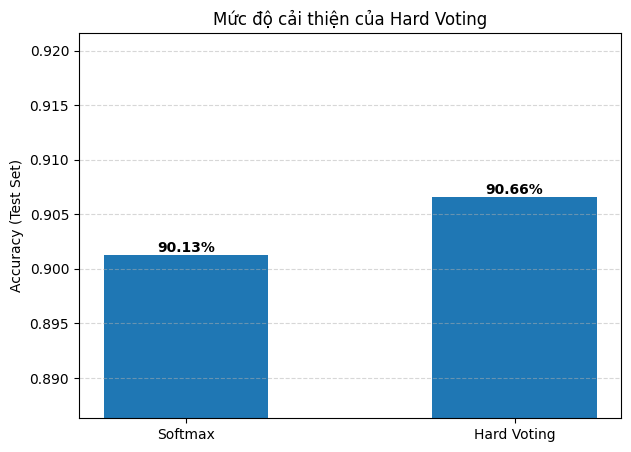

In [8]:
p_sm_test = predict_softmax(X_test, W_sm, b_sm)
p_nb_test = nb_model.predict(X_test)
p_dt_test = dt_model.predict(X_test)

acc_sm_test = np.mean(y_test == p_sm_test)
acc_nb_test = np.mean(y_test == p_nb_test)
acc_dt_test = np.mean(y_test == p_dt_test)

test_accuracies = [acc_sm_test, acc_nb_test, acc_dt_test]
best_single_test_acc = max(test_accuracies)
best_single_name = model_names[int(np.argmax(test_accuracies))]

improvement = acc_vote_test - best_single_test_acc

print(f"- Best Single ({best_single_name}): {best_single_test_acc*100:.2f}%")
print(f"- Hard Voting Ensemble: {acc_vote_test*100:.2f}%")

if improvement > 0:
    print(f"Voting tăng {improvement*100:.2f}%")
elif improvement == 0:
    print("Voting bằng best single")
else:
    print(f"Voting giảm {abs(improvement)*100:.2f}%")

plt.figure(figsize=(7, 5))
labels = [best_single_name, "Hard Voting"]
values = [best_single_test_acc, acc_vote_test]

plt.bar(labels, values, width=0.5)
plt.ylim(min(values) - 0.015, max(values) + 0.015)
plt.ylabel("Accuracy (Test Set)")
plt.title("Mức độ cải thiện của Hard Voting")
plt.grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(values):
    plt.text(i, v, f"{v*100:.2f}%", ha="center", va="bottom", fontweight="bold")
plt.show()


In [9]:
def confusion_matrix(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm

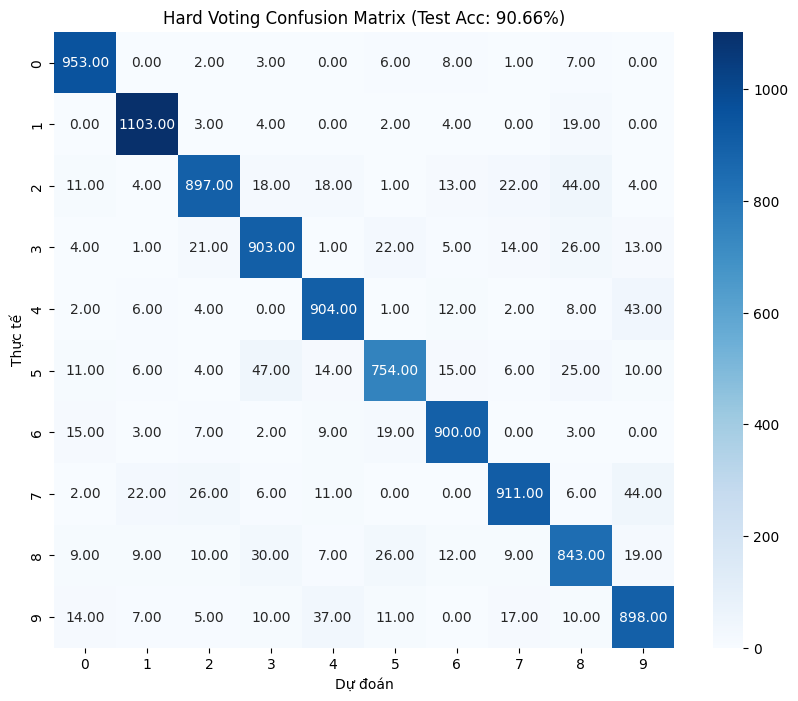

In [12]:
cm = confusion_matrix(y_test, vote_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"Hard Voting Confusion Matrix (Test Acc: {acc_vote_test*100:.2f}%)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

In [11]:
# Macro Precision / Macro Recall / Macro F1 (thủ công từ CM) =====
num_classes = cm.shape[0]
precision_list, recall_list, f1_list = [], [], []

for i in range(num_classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

print(f"Macro Precision: {sum(precision_list)/num_classes:.4f}")
print(f"Macro Recall: {sum(recall_list)/num_classes:.4f}")
print(f"Macro F1-score: {sum(f1_list)/num_classes:.4f}")


Macro Precision: 0.9059
Macro Recall: 0.9054
Macro F1-score: 0.9054


In [35]:
with open("hard_voting_model.pkl", "wb") as f: 
    pickle.dump(hv_model, f) 
print("Đã lưu hard_voting_model.pkl")

Đã lưu hard_voting_model.pkl


Hard voting ensemble không có quá trình tối ưu tham số nội tại.
Quá trình ‘huấn luyện’ ensemble được thực hiện bằng validation-based model selection: chọn mô hình leader có accuracy cao nhất trên tập validation để xử lý trường hợp hòa phiếu (1-1-1). Sau đó ensemble được cố định (frozen) và đánh giá trên tập test.

![alt text](image.png)

Weighted voting thường cho hiệu suất cao hơn khi có sự chênh lệch rõ ràng giữa các base model. Tuy nhiên, hard voting có thể đạt hiệu suất tương đương hoặc tốt hơn trong trường hợp các mô hình có độ đa dạng cao và sai khác nhau.